<a href="https://colab.research.google.com/github/HarshitaSmriti/customer-segmentation-api/blob/main/DataModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings("ignore")
pd.pandas.set_option("display.max_columns", 100)
df = pd.read_csv('/content/clustered_data.csv', sep=',')


In [ ]:
pd.set_option("display.max_columns",100)
pd.set_option("display.max_rows",100)

In [ ]:
# shape of dataset
print("Shape of dataset:", df.shape)

# first 5 rows
df.head()

# column names
df.columns

# info about dataset (dtypes + nulls)
df.info()

# statistical summary
df.describe()


Shape of dataset: (2240, 22)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 2240 non-null   int64  
 1   Education           2240 non-null   int64  
 2   Marital Status      2240 non-null   int64  
 3   Parental Status     2240 non-null   int64  
 4   Children            2240 non-null   int64  
 5   Income              2240 non-null   float64
 6   Total_Spending      2240 non-null   float64
 7   Days_as_Customer    2240 non-null   int64  
 8   Recency             2240 non-null   int64  
 9   Wines               2240 non-null   int64  
 10  Fruits              2240 non-null   int64  
 11  Meat                2240 non-null   int64  
 12  Fish                2240 non-null   float64
 13  Sweets              2240 non-null   int64  
 14  Gold                2240 non-null   float64
 15  Web                 2240 n

,Age,Education,Marital Status,Parental Status,Children,Income,Total_Spending,Days_as_Customer,Recency,Wines,Fruits,Meat,Fish,Sweets,Gold,Web,Catalog,Store,Discount Purchases,Total Promo,NumWebVisitsMonth,cluster
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,53.147768,2.460268,0.644643,0.715179,0.950446,51865.874554,605.779408,3401.043304,49.109375,302.112946,21.679018,150.873214,32.115848,21.937946,39.487723,4.084821,2.662054,5.790179,2.325000,0.297768,5.316518,1.155804
std,11.771725,1.004337,0.478728,0.451430,0.751803,20936.104821,602.189559,232.229893,28.962453,331.057356,27.257348,178.816658,40.361485,27.540334,39.927508,2.778714,2.923101,3.250958,1.932238,0.678381,2.426645,0.810446
min,26.000000,0.000000,0.000000,0.000000,0.000000,1730.000000,5.000000,2889.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,45.000000,2.000000,0.000000,0.000000,0.000000,35538.750000,68.750000,3229.750000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,2.000000,0.000000,3.000000,1.000000,0.000000,3.000000,0.000000
50%,52.000000,2.000000,1.000000,1.000000,1.000000,51381.500000,396.000000,3402.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,4.000000,2.000000,5.000000,2.000000,0.000000,6.000000,1.000000
75%,63.000000,3.000000,1.000000,1.000000,1.000000,68289.750000,1045.500000,3574.250000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,6.000000,4.000000,8.000000,3.000000,0.000000,7.000000,2.000000
max,90.000000,4.000000,1.000000,1.000000,3.000000,117416.250000,2510.625000,3952.000000,99.000000,1225.000000,81.000000,556.000000,120.500000,81.000000,126.500000,27.000000,28.000000,13.000000,15.000000,4.000000,20.000000,2.000000


In [ ]:
df.dtypes

,0
Age,int64
Education,int64
Marital Status,int64
Parental Status,int64
Children,int64
Income,float64
Total_Spending,float64
Days_as_Customer,int64
Recency,int64
Wines,int64


In [ ]:
df.shape

(2240, 22)

In [ ]:
df.describe()

,Age,Education,Marital Status,Parental Status,Children,Income,Total_Spending,Days_as_Customer,Recency,Wines,Fruits,Meat,Fish,Sweets,Gold,Web,Catalog,Store,Discount Purchases,Total Promo,NumWebVisitsMonth,cluster
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,53.147768,2.460268,0.644643,0.715179,0.950446,51865.874554,605.779408,3401.043304,49.109375,302.112946,21.679018,150.873214,32.115848,21.937946,39.487723,4.084821,2.662054,5.790179,2.325000,0.297768,5.316518,1.155804
std,11.771725,1.004337,0.478728,0.451430,0.751803,20936.104821,602.189559,232.229893,28.962453,331.057356,27.257348,178.816658,40.361485,27.540334,39.927508,2.778714,2.923101,3.250958,1.932238,0.678381,2.426645,0.810446
min,26.000000,0.000000,0.000000,0.000000,0.000000,1730.000000,5.000000,2889.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,45.000000,2.000000,0.000000,0.000000,0.000000,35538.750000,68.750000,3229.750000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,2.000000,0.000000,3.000000,1.000000,0.000000,3.000000,0.000000
50%,52.000000,2.000000,1.000000,1.000000,1.000000,51381.500000,396.000000,3402.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,4.000000,2.000000,5.000000,2.000000,0.000000,6.000000,1.000000
75%,63.000000,3.000000,1.000000,1.000000,1.000000,68289.750000,1045.500000,3574.250000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,6.000000,4.000000,8.000000,3.000000,0.000000,7.000000,2.000000
max,90.000000,4.000000,1.000000,1.000000,3.000000,117416.250000,2510.625000,3952.000000,99.000000,1225.000000,81.000000,556.000000,120.500000,81.000000,126.500000,27.000000,28.000000,13.000000,15.000000,4.000000,20.000000,2.000000


In [ ]:
#Check null and dtypes

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 2240 non-null   int64  
 1   Education           2240 non-null   int64  
 2   Marital Status      2240 non-null   int64  
 3   Parental Status     2240 non-null   int64  
 4   Children            2240 non-null   int64  
 5   Income              2240 non-null   float64
 6   Total_Spending      2240 non-null   float64
 7   Days_as_Customer    2240 non-null   int64  
 8   Recency             2240 non-null   int64  
 9   Wines               2240 non-null   int64  
 10  Fruits              2240 non-null   int64  
 11  Meat                2240 non-null   int64  
 12  Fish                2240 non-null   float64
 13  Sweets              2240 non-null   int64  
 14  Gold                2240 non-null   float64
 15  Web                 2240 non-null   int64  
 16  Catalo

#1.Finding features with NaN

In [ ]:
## these are the features with nan value
features_with_na = [features for features in df.columns if df[features].isnull().sum() >= 1]

print("Features with NaN:", features_with_na)

if len(features_with_na) == 0:
    print("No missing values in the dataset")
else:
    for feature in features_with_na:
        print(feature, np.round(df[feature].isnull().mean() * 100, 5), '% missing values')

    ## statistics on numerical columns (Null cols)
    df[features_with_na].select_dtypes(exclude='object').describe()

    ## fill numeric NaN with median
    for feature in features_with_na:
        if df[feature].dtype != 'object':
            df[feature].fillna(df[feature].median(), inplace=True)

Features with NaN: []
No missing values in the dataset


In [ ]:
# check duplicate rows
df.duplicated().sum()



np.int64(204)

In [ ]:
# drop duplicate rows
df.drop_duplicates(inplace=True)
print("After dropping duplicates, shape:", df.shape)


After dropping duplicates, shape: (2036, 22)


In [ ]:
## find columns with only 1 unique value (constant features)
constant_features = [feature for feature in df.columns if df[feature].nunique() == 1]

print("Constant features:", constant_features)


Constant features: []


In [ ]:
# Find constant columns (columns with only 1 unique value)
constant_features = [col for col in df.columns if df[col].nunique() == 1]

print("Constant columns:", constant_features)

# Drop them
df.drop(columns=constant_features, inplace=True)

print("Shape after dropping constant columns:", df.shape)


constant_features = [col for col in df.columns if df[col].nunique() == 1 and col != 'cluster']


Constant columns: []
Shape after dropping constant columns: (2036, 22)


# Starting EDA from here:

Let's convert the datetime column to pandas datetime format

In [ ]:
# Define numerical and categorical columns (explicit style)

categorical_features = ['Education', 'Marital Status', 'Parental Status', 'cluster']
numerical_features = [col for col in df.columns if col not in categorical_features]

print("Categorical features (encoded):", categorical_features)
print("Numerical features:", numerical_features)


#in our dataset there are effectively no object dtype categorical features. but for EDA and understanding we have to treat some as categorical


Categorical features (encoded): ['Education', 'Marital Status', 'Parental Status', 'cluster']
Numerical features: ['Age', 'Children', 'Income', 'Total_Spending', 'Days_as_Customer', 'Recency', 'Wines', 'Fruits', 'Meat', 'Fish', 'Sweets', 'Gold', 'Web', 'Catalog', 'Store', 'Discount Purchases', 'Total Promo', 'NumWebVisitsMonth']


# Feature Information:

- **People / Demographics**

  - **Age:** Customer’s age  
  - **Education:** Customer’s education level (encoded)  
  - **Marital Status:** Customer’s marital status (encoded)  
  - **Parental Status:** Indicates whether the customer has children (1 = Yes, 0 = No)  
  - **Children:** Number of children in the customer’s household  
  - **Income:** Customer’s yearly household income  
  - **Days_as_Customer:** Number of days since the customer joined the company  
  - **Recency:** Number of days since the customer’s last purchase  

- **Products (Spending in Last Period)**

  - **Wines:** Amount spent on wine  
  - **Fruits:** Amount spent on fruits  
  - **Meat:** Amount spent on meat  
  - **Fish:** Amount spent on fish  
  - **Sweets:** Amount spent on sweets  
  - **Gold:** Amount spent on gold products  
  - **Total_Spending:** Total amount spent across all product categories  

- **Purchase Channels**

  - **Web:** Number of purchases made through the website  
  - **Catalog:** Number of purchases made through catalog  
  - **Store:** Number of purchases made in physical stores  
  - **NumWebVisitsMonth:** Number of visits to the website in the last month  

- **Promotions / Discounts**

  - **Discount Purchases:** Number of purchases made with discounts  
  - **Total Promo:** Number of promotional offers accepted by the customer  

- **Engineered Features**

  - **Family_Size:** Total number of people in the customer’s household  
  - **Spending_per_Day:** Average spending per day  
  - **Digital_Engagement:** Online interaction score  
  - **Offline_Engagement:** Offline interaction score  
  - **Discount_Ratio:** Ratio of discount purchases to total purchases  
  - **Premium_Ratio:** Ratio of premium product spending  
  - **Freshness_Score:** Score representing how recently the customer purchased  
  - **Variety_Index:** Measure of product variety purchased  

- **Target / Label**

  - **cluster:** Cluster label assigned to each customer after segmentation  


In [ ]:
df[categorical_features[0]].value_counts().count()

np.int64(5)

In [ ]:
# proportion of count data on categorical columns
for col in categorical_features:
    print(df[col].value_counts(normalize=True) * 100)
    print('---------------------------')

Education
2    50.294695
4    21.611002
3    16.552063
1     9.135560
0     2.406680
Name: proportion, dtype: float64
---------------------------
Marital Status
1    64.096267
0    35.903733
Name: proportion, dtype: float64
---------------------------
Parental Status
1    71.807466
0    28.192534
Name: proportion, dtype: float64
---------------------------
cluster
2    41.699411
1    32.023576
0    26.277014
Name: proportion, dtype: float64
---------------------------


# Univariate Analysis

- Univariate analysis refers to the analysis of a single variable.  
- The purpose of univariate analysis is to understand the distribution of values for one variable.  

**Other Types of Analysis:**
- **Bivariate Analysis:** Analysis of two variables  
- **Multivariate Analysis:** Analysis of more than two variables  


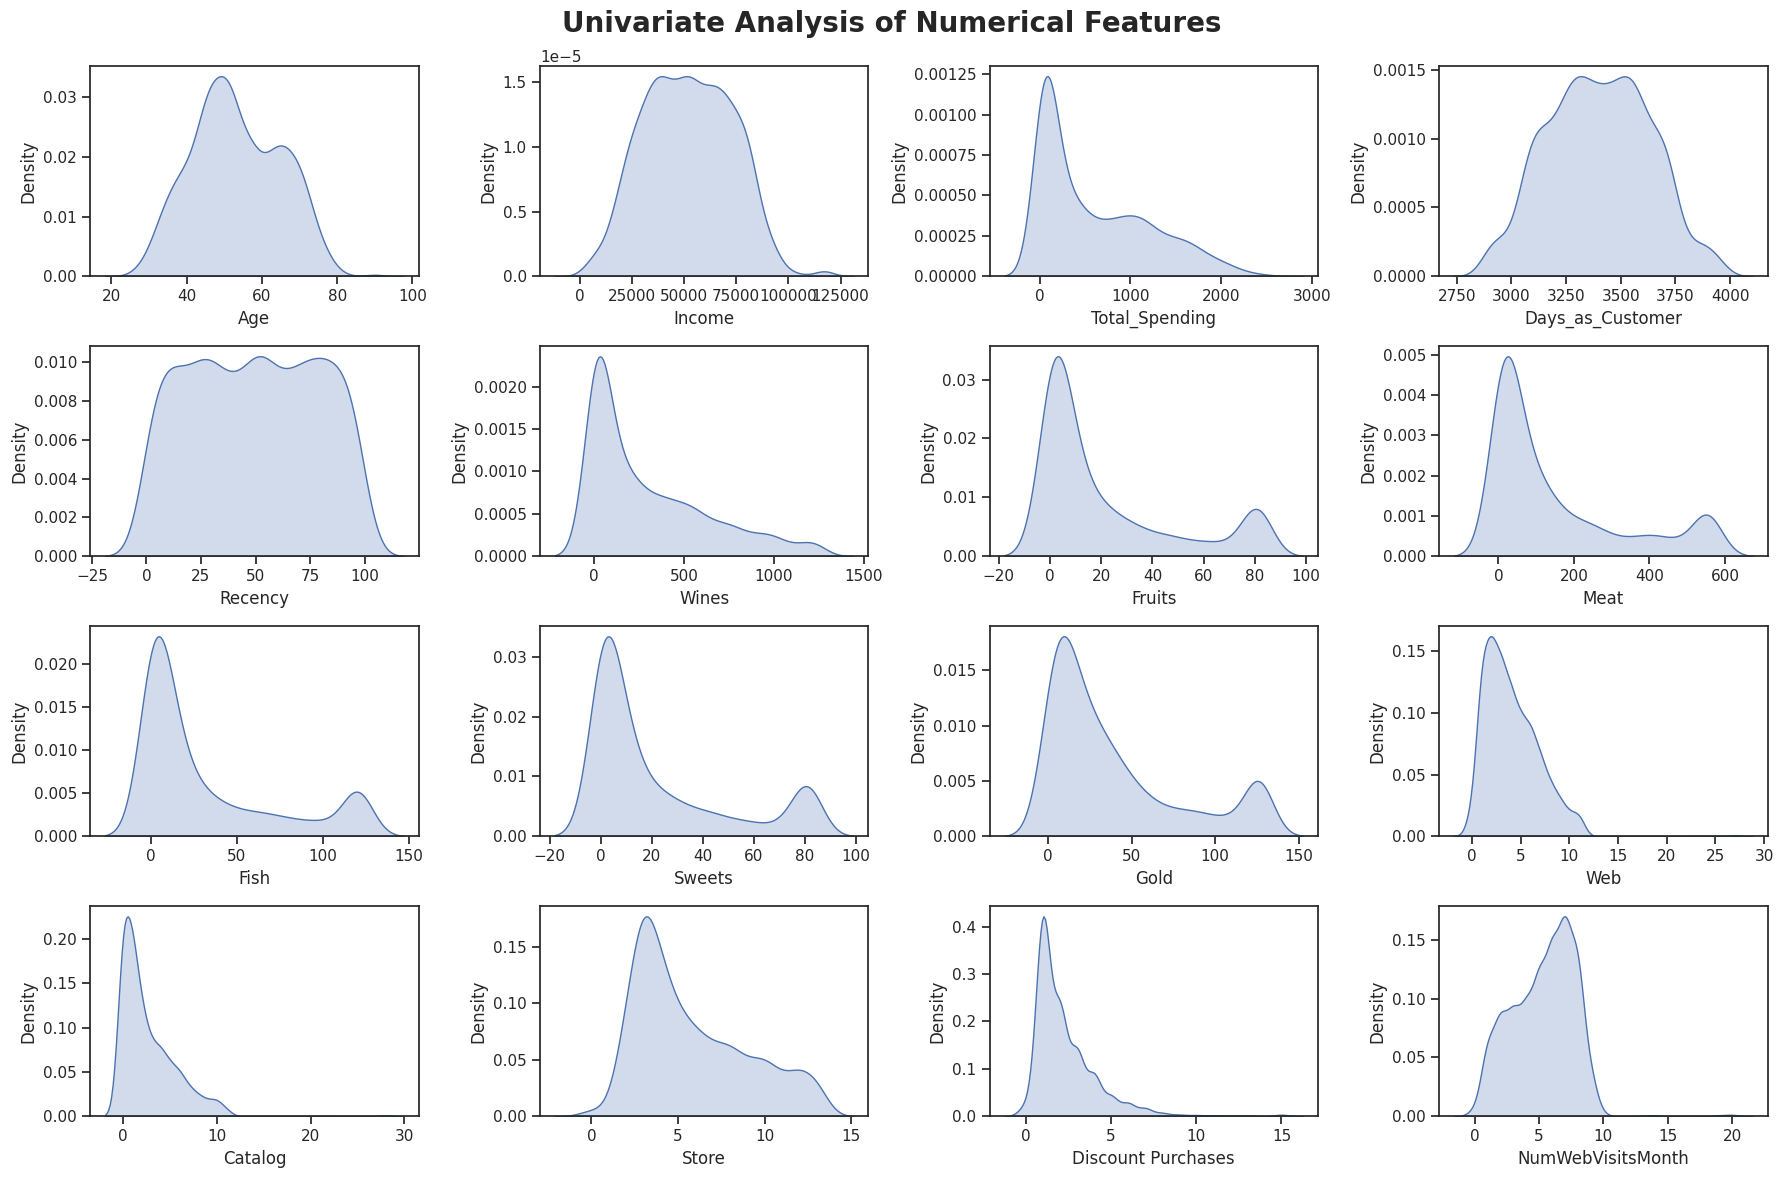

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_features = [
    'Age','Income','Total_Spending','Days_as_Customer','Recency',
    'Wines','Fruits','Meat','Fish','Sweets','Gold',
    'Web','Catalog','Store','Discount Purchases','NumWebVisitsMonth'
]

plt.figure(figsize=(18, 12))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=20, fontweight='bold')

for i, col in enumerate(numerical_features):
    plt.subplot(4, 4, i+1)
    sns.kdeplot(df[col], fill=True)
    plt.xlabel(col)

plt.tight_layout()
plt.show()


### Report of Univariate Analysis

1. **Age** is slightly right-skewed with most values lying between middle-aged and older customers, and a few outliers.  
2. **Income** is right-skewed with most values in the lower to mid-income range and some high-income outliers.  
3. **Days_as_Customer** is concentrated around higher values, showing most customers are long-term customers.  
4. **Recency** shows variation across customers, indicating different levels of recent engagement.  
5. **Wines, Meat, Gold** spending are right-skewed with most customers spending less and a few heavy spenders.  
6. **Fruits, Fish, Sweets** have low average spending with right-skewed distributions and outliers.  
7. **Web, Catalog, Store** purchases show different channel preferences with right-skewed distributions.  
8. **Discount Purchases** is right-skewed with most customers making few discounted purchases.  
9. **NumWebVisitsMonth** is right-skewed with most customers visiting a limited number of times and some heavy visitors.  
10. No constant numerical features were found in the dataset after cleaning.


In [ ]:
constant_features = [col for col in df.columns if df[col].nunique() == 1]
print("Constant columns:", constant_features)

if constant_features:
    df = df.drop(columns=constant_features)
    print("Dropped constant columns:", constant_features)

    #kaise aya i will learn


Constant columns: []


In [ ]:
print(df.columns.tolist())
# 👉 Purpose: To clearly see all feature names in list format, which helps in feature selection and preprocessing

['Age', 'Education', 'Marital Status', 'Parental Status', 'Children', 'Income', 'Total_Spending', 'Days_as_Customer', 'Recency', 'Wines', 'Fruits', 'Meat', 'Fish', 'Sweets', 'Gold', 'Web', 'Catalog', 'Store', 'Discount Purchases', 'Total Promo', 'NumWebVisitsMonth', 'cluster']


In [ ]:
# recreate engineered features
df['Family_Size'] = df['Marital Status'] + df['Children'] + 1

df['Spending_per_Day'] = df['Total_Spending'] / (df['Days_as_Customer'] + 1)

df['Digital_Engagement'] = df['Web'] + df['NumWebVisitsMonth']

df['Offline_Engagement'] = df['Store'] + df['Catalog']

df['Discount_Ratio'] = df['Discount Purchases'] / (df['Web'] + df['Store'] + df['Catalog'] + 1)

df['Premium_Ratio'] = (df['Wines'] + df['Gold']) / (df['Total_Spending'] + 1)

df['Freshness_Score'] = 1 / (df['Recency'] + 1)

df['Variety_Index'] = (
    (df['Wines'] > 0).astype(int) +
    (df['Fruits'] > 0).astype(int) +
    (df['Meat'] > 0).astype(int) +
    (df['Fish'] > 0).astype(int) +
    (df['Sweets'] > 0).astype(int) +
    (df['Gold'] > 0).astype(int)
)

print("New columns added:")
print([c for c in df.columns if c not in ['Age', 'Education', 'Marital Status', 'Parental Status', 'Children', 'Income',
       'Total_Spending', 'Days_as_Customer', 'Recency', 'Wines', 'Fruits', 'Meat', 'Fish', 'Sweets', 'Gold', 'Web',
       'Catalog', 'Store', 'Discount Purchases', 'Total Promo', 'NumWebVisitsMonth', 'cluster']])


New columns added:
['Family_Size', 'Spending_per_Day', 'Digital_Engagement', 'Offline_Engagement', 'Discount_Ratio', 'Premium_Ratio', 'Freshness_Score', 'Variety_Index']


# Box plot(outlier view)

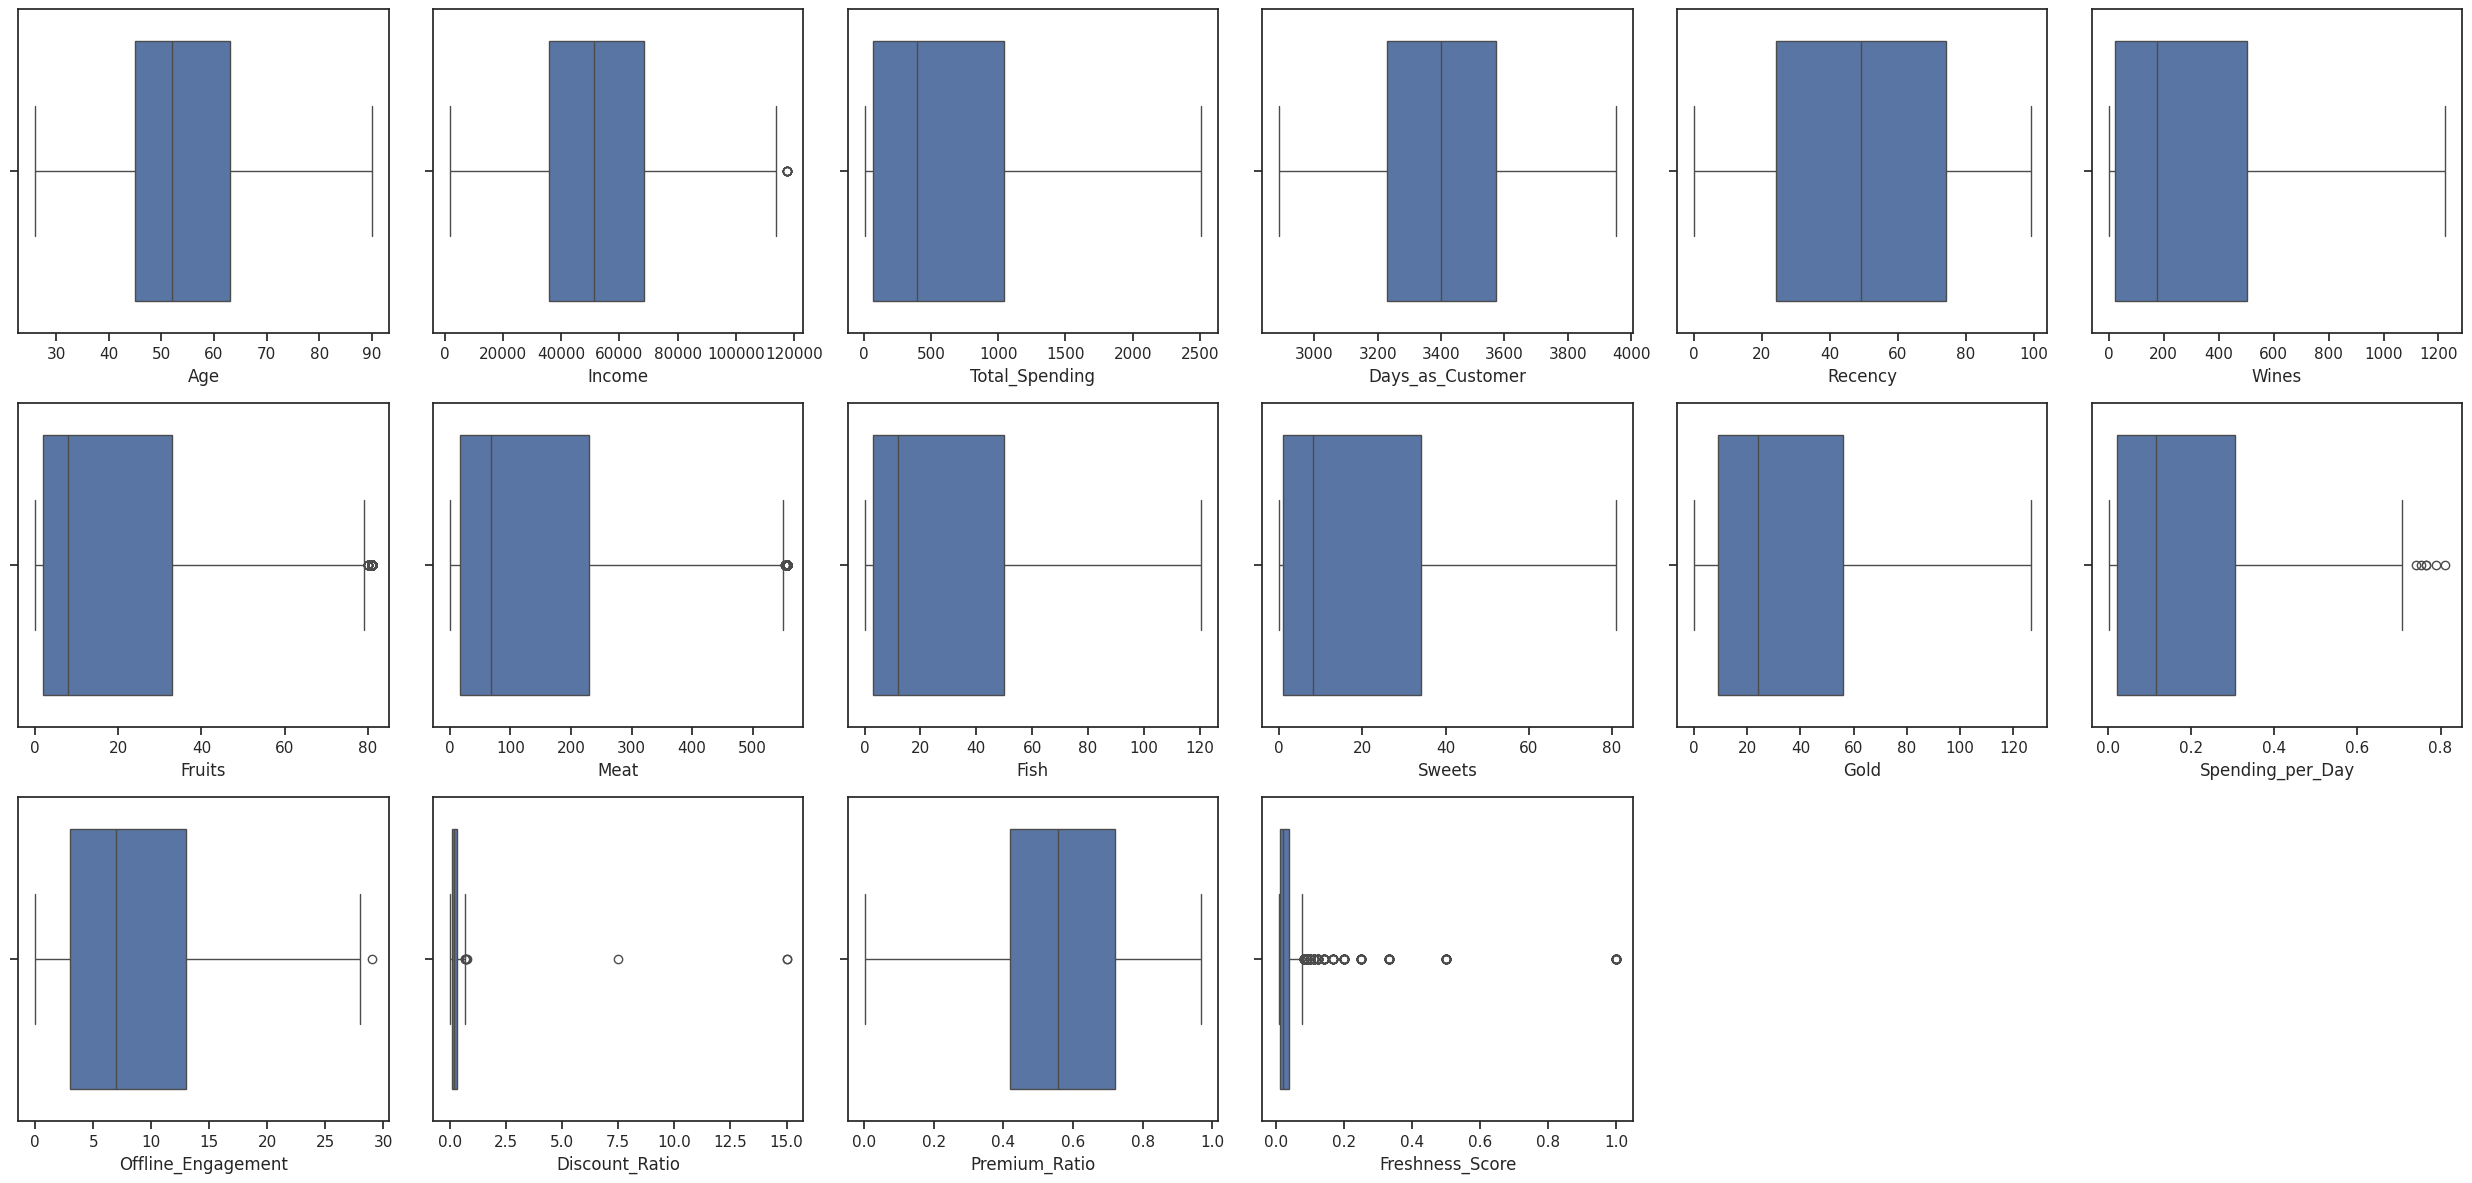

In [ ]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

cont_features = continuous_features.copy()

n_features = len(cont_features)
cols = 6
rows = math.ceil(n_features / cols)

plt.figure(figsize=(25, 4 * rows))

for i in range(n_features):
    plt.subplot(rows, cols, i + 1)
    sns.set_style('ticks')
    plt.xlabel(cont_features[i])
    sns.boxplot(x=df[cont_features[i]])

plt.tight_layout()
plt.show()


# Categorical Features


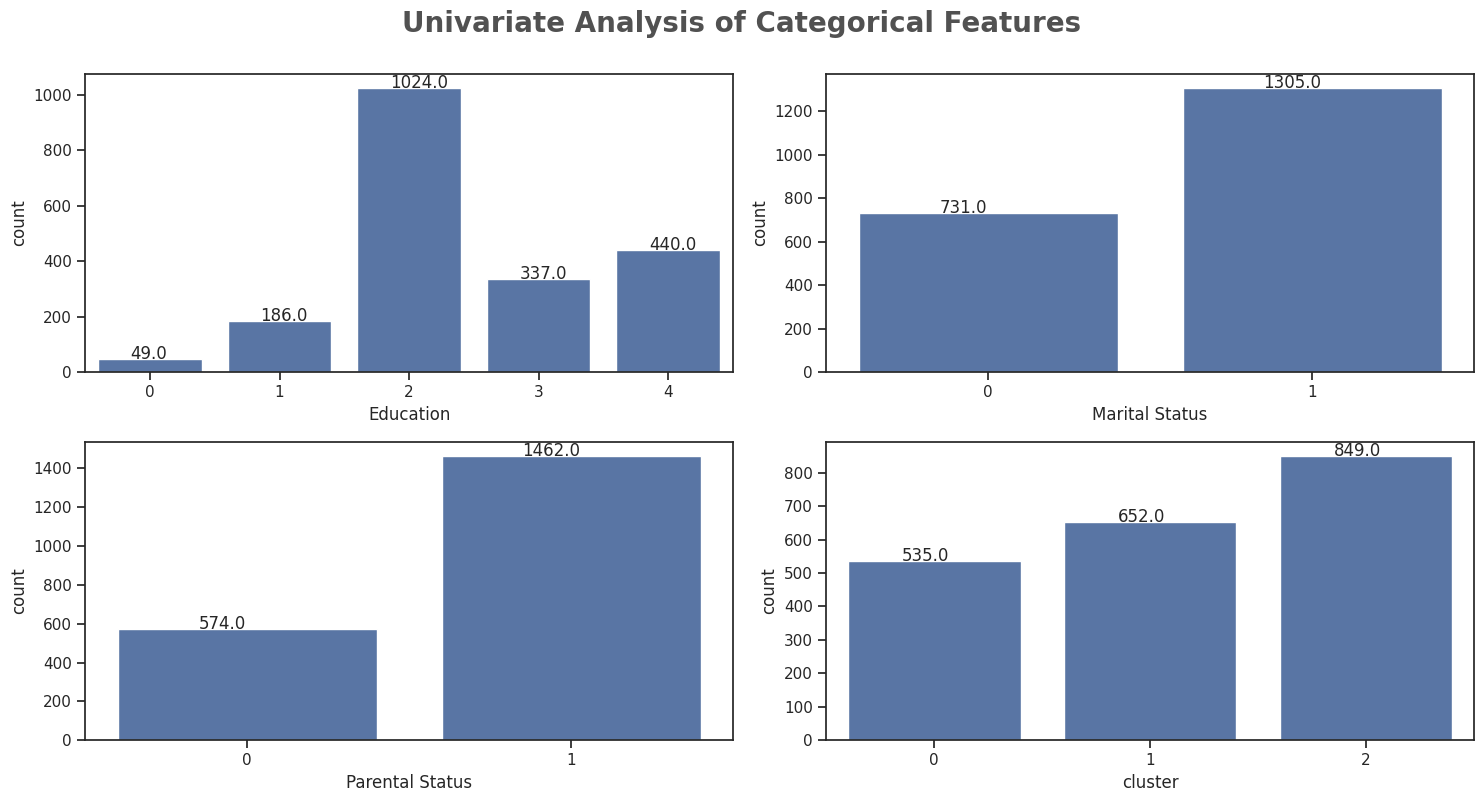

In [ ]:
# categorical columns
plt.figure(figsize=(15, 8))
plt.suptitle('Univariate Analysis of Categorical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(categorical_features)):
    plt.subplot(2, 2, i+1)
    ax = sns.countplot(x=df[categorical_features[i]])
    if df[categorical_features[i]].value_counts().count() < 10:
        for p in ax.patches:
            ax.annotate('{:.1f}'.format(p.get_height()), (p.get_x()+0.25, p.get_height()+0.01))
    plt.xlabel(categorical_features[i])
    plt.tight_layout()




### Report

- **For column Education**
  - Most of the customers fall into the Graduation category.
  - PhD, Master Education, Basic and 2nd Cycle categories are also present.

- **For column Marital Status**
  - A large number of customers are married.
  - Single, divorced and widowed customers are noticeable, while rare categories are very few.

- **For column Parental Status**
  - Majority of customers have children.
  - A smaller portion of customers do not have children.

- **For column cluster**
  - Customers are distributed across multiple clusters with noticeable differences in size.


In [ ]:
df1 = df.copy()

df1['Year'] = pd.to_datetime(df1['Days_as_Customer'], errors='coerce')
# If you have actual join date column, replace above line with:
# df1['Year'] = pd.to_datetime(df1['Dt_Customer']).dt.year

# If you only have Days_as_Customer, skip year plot
# Else, use the real date column like below:

# df1['Year'] = pd.to_datetime(df1['Dt_Customer']).dt.year
# customer_joined_per_year = df1.groupby(by='Year', axis=0)['Age'].count().reset_index()
# customer_joined_per_year.columns = ['YEAR', 'CUSTOMER_JOINED']

# sns.barplot(data=customer_joined_per_year, x='YEAR', y='CUSTOMER_JOINED')
# plt.show()


#Count of features based on years

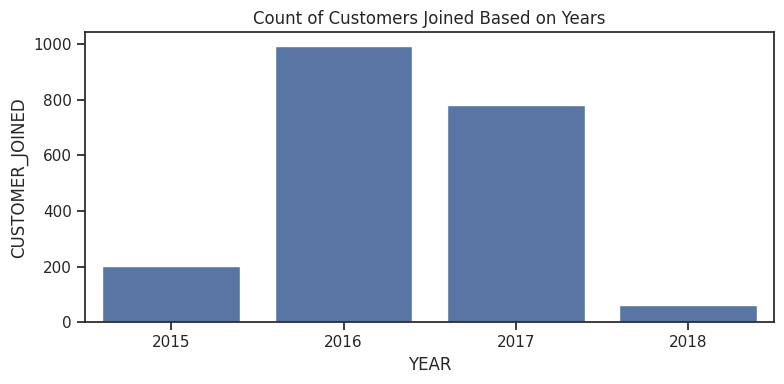

In [ ]:
df1 = df.copy()

# create a join date from Days_as_Customer
today = pd.Timestamp.today().normalize()
df1["Join_Date"] = today - pd.to_timedelta(df1["Days_as_Customer"], unit='D')

df1["Year"] = df1["Join_Date"].dt.year

customer_joined_per_year = df1.groupby(by="Year", axis=0)[['Age']].count()
customer_joined_per_year = customer_joined_per_year.reset_index()
customer_joined_per_year.columns = ['YEAR', 'CUSTOMER_JOINED']

plt.figure(figsize=(8, 4))
sns.barplot(data=customer_joined_per_year, x='YEAR', y='CUSTOMER_JOINED')
plt.xlabel('YEAR')
plt.ylabel('CUSTOMER_JOINED')
plt.title('Count of Customers Joined Based on Years')
plt.tight_layout()




### Report

- The bar plot shows the number of customers who joined the company across different years.  
- Most customers appear to have joined in recent years, indicating growth in customer acquisition over time.  
- Fewer customers are observed in earlier years, suggesting that the customer base has expanded in later periods.  
- The trend indicates increasing popularity of the company in recent years.  
- This pattern can help businesses understand customer acquisition trends and plan marketing strategies accordingly.


# Multivariate Analysis.

Multivariate analysis refers to the analysis of more than two variables at a time.  
It helps in understanding relationships and patterns among multiple features simultaneously.

### Multivariate Analysis (Code – Correlation Heatmap)

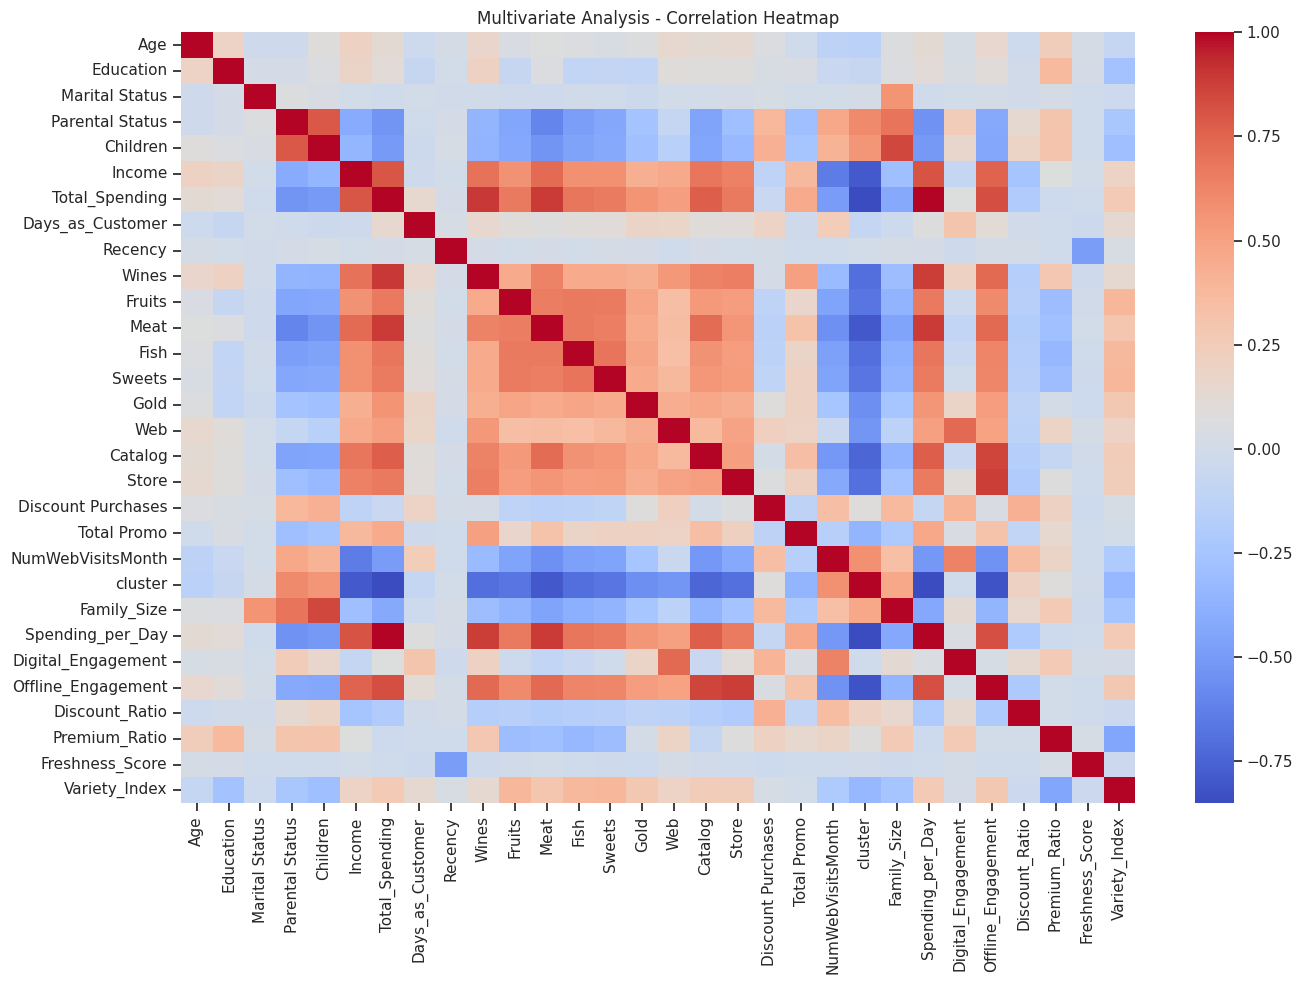

In [ ]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot=False)
plt.title('Multivariate Analysis - Correlation Heatmap')
plt.tight_layout()

### Multivariate Analysis (Code – Pairplot for Important Features)

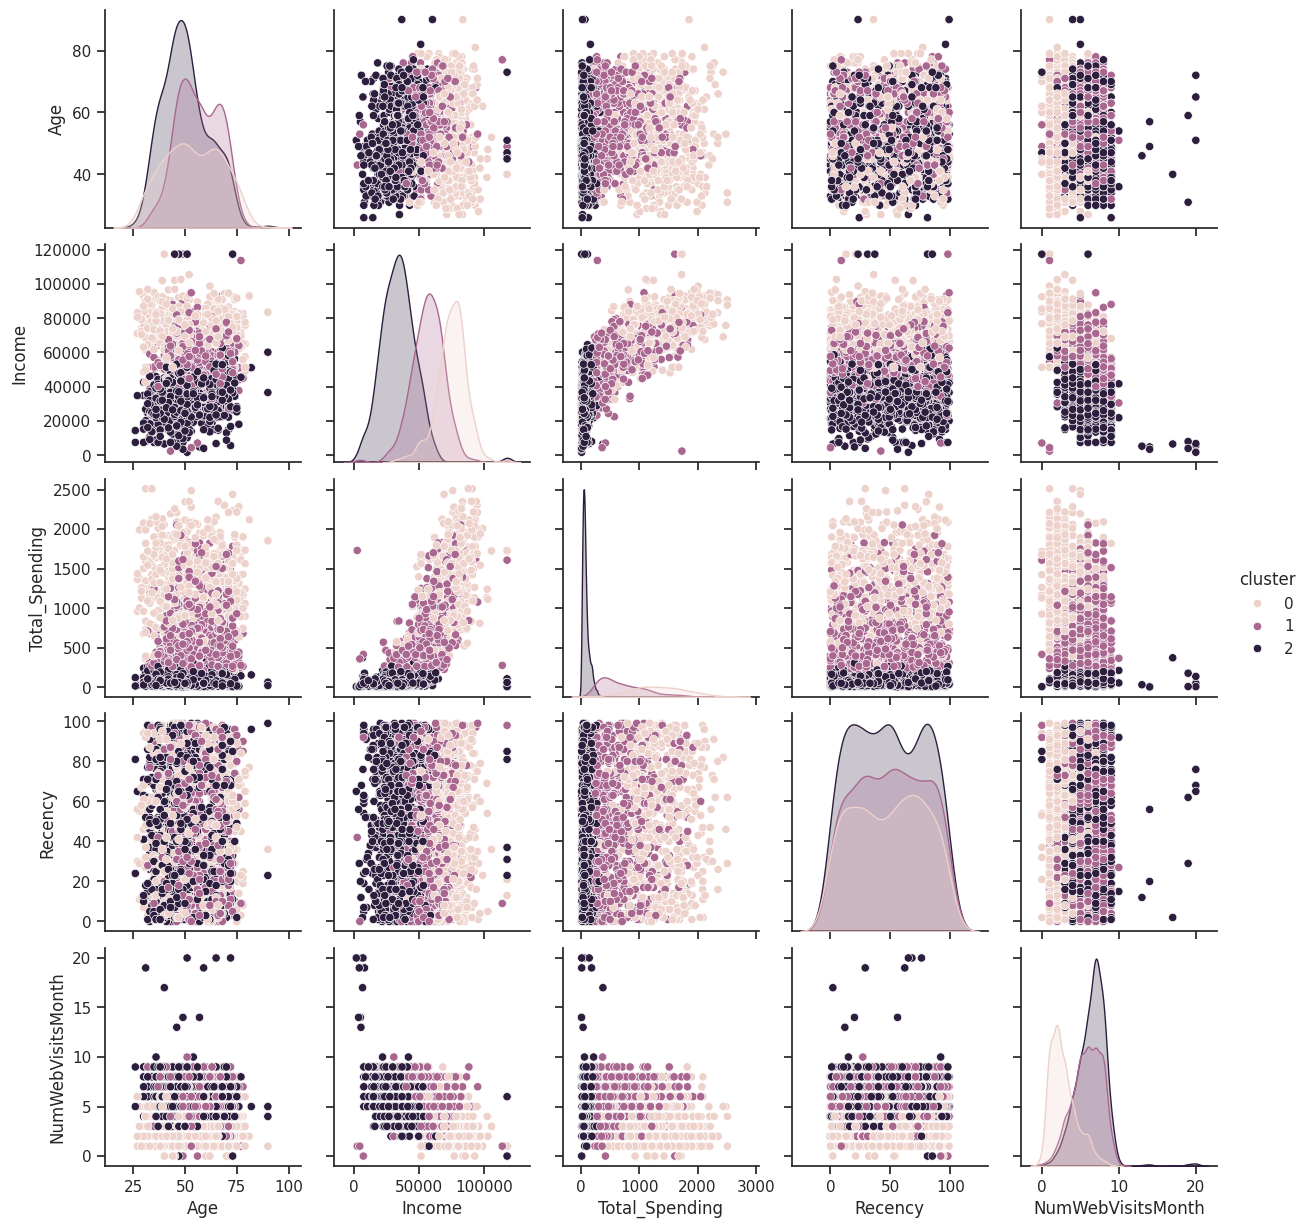

In [ ]:
important_features = ['Age', 'Income', 'Total_Spending', 'Recency', 'NumWebVisitsMonth', 'cluster']

sns.pairplot(df[important_features], hue='cluster', diag_kind='kde')
plt.show()


### Report

- The correlation heatmap shows relationships among numerical features.  
- Product-wise spending features show positive correlation with Total_Spending.  
- Income shows moderate correlation with Total_Spending, indicating higher income customers tend to spend more.  
- Recency is negatively correlated with Total_Spending, suggesting recently active customers tend to spend more.  
- Pairplot visualization shows clear separation of clusters based on spending behavior and income.  
- Multivariate analysis highlights how multiple features together help in differentiating customer segments.


#Feature Engineering:

In [ ]:
# Feature Engineering
df['Family_Size'] = df['Children'] + 1
df['Spending_per_Day'] = df['Total_Spending'] / df['Days_as_Customer']
df['Digital_Engagement'] = df['Web'] + df['NumWebVisitsMonth']
df['Offline_Engagement'] = df['Store'] + df['Catalog']
df['Discount_Ratio'] = df['Discount Purchases'] / (df['Web'] + df['Catalog'] + df['Store'] + 1)
df['Premium_Ratio'] = (df['Wines'] + df['Gold']) / (df['Total_Spending'] + 1)


#Feature Scaling:

In [ ]:
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['cluster'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


#Feature Extraction

In [ ]:
df.head()

,Age,Education,Marital Status,Parental Status,Children,Income,Total_Spending,Days_as_Customer,Recency,Wines,Fruits,Meat,Fish,Sweets,Gold,Web,Catalog,Store,Discount Purchases,Total Promo,NumWebVisitsMonth,cluster,Family_Size,Spending_per_Day,Digital_Engagement,Offline_Engagement,Discount_Ratio,Premium_Ratio,Freshness_Score,Variety_Index
0,65,2,0,0,0,58138.0,1617.0,3860,58,635,81,546,120.5,81,88.0,8,10,4,3,0,7,0,1,0.418912,15,14,0.130435,0.446848,0.016949,6
1,68,2,0,1,2,46344.0,27.0,3014,38,11,1,6,2.0,1,6.0,1,1,2,2,0,5,2,3,0.008958,6,3,0.400000,0.607143,0.025641,6
2,57,2,1,0,0,71613.0,776.0,3361,26,426,49,127,111.0,21,42.0,8,2,10,1,0,4,0,1,0.230884,12,12,0.047619,0.602317,0.037037,6
3,38,2,1,1,1,26646.0,53.0,2954,26,11,4,20,10.0,3,5.0,2,0,4,2,0,6,2,2,0.017942,8,4,0.285714,0.296296,0.037037,6
4,41,4,1,1,1,58293.0,422.0,3210,94,173,43,118,46.0,27,15.0,5,3,6,5,0,5,1,2,0.131464,10,9,0.333333,0.444444,0.010526,6


In [ ]:
import numpy as np
import pandas as pd

df = df.copy()

# 1️⃣ Family Size (already have Marital Status + Children)
df['Family_Size'] = df['Marital Status'] + df['Children'] + 1

# 2️⃣ Spending per Day (behavioral intensity)
df['Spending_per_Day'] = df['Total_Spending'] / (df['Days_as_Customer'] + 1)

# 3️⃣ Digital Engagement Score (online activity)
df['Digital_Engagement'] = df['Web'] + df['NumWebVisitsMonth']

# 4️⃣ Offline Engagement Score (store + catalog)
df['Offline_Engagement'] = df['Store'] + df['Catalog']

# 5️⃣ Discount Sensitivity (how much they buy on discount)
df['Discount_Ratio'] = df['Discount Purchases'] / (df['Web'] + df['Store'] + df['Catalog'] + 1)

# 6️⃣ Premium Product Ratio (wine + gold as premium items)
df['Premium_Ratio'] = (df['Wines'] + df['Gold']) / (df['Total_Spending'] + 1)

# 7️⃣ Freshness Score (recently active customers higher score)
df['Freshness_Score'] = 1 / (df['Recency'] + 1)

# 8️⃣ Variety Index (how many categories they buy from)
df['Variety_Index'] = (
    (df['Wines'] > 0).astype(int) +
    (df['Fruits'] > 0).astype(int) +
    (df['Meat'] > 0).astype(int) +
    (df['Fish'] > 0).astype(int) +
    (df['Sweets'] > 0).astype(int) +
    (df['Gold'] > 0).astype(int)
)

df.head()


,Age,Education,Marital Status,Parental Status,Children,Income,Total_Spending,Days_as_Customer,Recency,Wines,Fruits,Meat,Fish,Sweets,Gold,Web,Catalog,Store,Discount Purchases,Total Promo,NumWebVisitsMonth,cluster,Family_Size,Spending_per_Day,Digital_Engagement,Offline_Engagement,Discount_Ratio,Premium_Ratio,Freshness_Score,Variety_Index
0,65,2,0,0,0,58138.0,1617.0,3860,58,635,81,546,120.5,81,88.0,8,10,4,3,0,7,0,1,0.418803,15,14,0.130435,0.446848,0.016949,6
1,68,2,0,1,2,46344.0,27.0,3014,38,11,1,6,2.0,1,6.0,1,1,2,2,0,5,2,3,0.008955,6,3,0.400000,0.607143,0.025641,6
2,57,2,1,0,0,71613.0,776.0,3361,26,426,49,127,111.0,21,42.0,8,2,10,1,0,4,0,2,0.230815,12,12,0.047619,0.602317,0.037037,6
3,38,2,1,1,1,26646.0,53.0,2954,26,11,4,20,10.0,3,5.0,2,0,4,2,0,6,2,3,0.017936,8,4,0.285714,0.296296,0.037037,6
4,41,4,1,1,1,58293.0,422.0,3210,94,173,43,118,46.0,27,15.0,5,3,6,5,0,5,1,3,0.131423,10,9,0.333333,0.444444,0.010526,6


In [ ]:
print(df.columns.tolist())


['Age', 'Education', 'Marital Status', 'Parental Status', 'Children', 'Income', 'Total_Spending', 'Days_as_Customer', 'Recency', 'Wines', 'Fruits', 'Meat', 'Fish', 'Sweets', 'Gold', 'Web', 'Catalog', 'Store', 'Discount Purchases', 'Total Promo', 'NumWebVisitsMonth', 'cluster', 'Family_Size', 'Spending_per_Day', 'Digital_Engagement', 'Offline_Engagement', 'Discount_Ratio', 'Premium_Ratio', 'Freshness_Score', 'Variety_Index']


## Numeric Features


In [ ]:
num_features = [feature for feature in df.columns if df[feature].dtype != 'O' and feature != 'cluster']
print('Num of Numerical Features :', len(num_features))


Num of Numerical Features : 29


## Categorical Features


In [ ]:
cat_features = [feature for feature in df.columns if df[feature].dtype == 'O' and feature != 'cluster']
print('Num of Categorical Features :', len(cat_features))


Num of Categorical Features : 0


## Discrete Features

In [ ]:
discrete_features = [feature for feature in num_features if len(df[feature].unique()) <= 25 and feature != 'cluster']
print('Num of Discrete Features :', len(discrete_features))


Num of Discrete Features : 13


## Continues Features

In [ ]:
continuous_features = [feature for feature in num_features if feature not in discrete_features and feature != 'cluster']
print('Num of Continuous Features :', len(continuous_features))


Num of Continuous Features : 16


## Detecting Outlier and Capping it

In [ ]:
def detect_outliers(col):
    # Finding the IQR
    percentile25 = df[col].quantile(0.25)
    percentile75 = df[col].quantile(0.75)

    print('\n ####', col, '####')
    print("percentile25:", percentile25)
    print("percentile75:", percentile75)

    iqr = percentile75 - percentile25
    upper_limit = percentile75 + 1.5 * iqr
    lower_limit = percentile25 - 1.5 * iqr

    print("Upper limit:", upper_limit)
    print("Lower limit:", lower_limit)

    df.loc[(df[col] > upper_limit), col] = upper_limit
    df.loc[(df[col] < lower_limit), col] = lower_limit

    return df


**Why are we capping it and why not trim it ?**
* Trimming outliers may result in the removal of a large number of records from this dataset as we have already very less rows so this isn’t desirable in this case since columns other than the ones containing the outlier values may contain useful information.

* In this cases, you can use outlier capping to replace the outlier values with a maximum or minimum capped values. Be warned, this manipulates our data but we can replace outlier values by the upper and lower limit calculated using the IQR range.

In [ ]:
for col in continuous_features:
    df = detect_outliers(col)



 #### Age ####
percentile25: 45.0
percentile75: 63.0
Upper limit: 90.0
Lower limit: 18.0

 #### Income ####
percentile25: 35703.25
percentile75: 68325.0
Upper limit: 117257.625
Lower limit: -13229.375

 #### Total_Spending ####
percentile25: 68.75
percentile75: 1045.5
Upper limit: 2510.625
Lower limit: -1396.375

 #### Days_as_Customer ####
percentile25: 3228.0
percentile75: 3572.0
Upper limit: 4088.0
Lower limit: 2712.0

 #### Recency ####
percentile25: 24.0
percentile75: 74.0
Upper limit: 149.0
Lower limit: -51.0

 #### Wines ####
percentile25: 23.0
percentile75: 504.0
Upper limit: 1225.5
Lower limit: -698.5

 #### Fruits ####
percentile25: 2.0
percentile75: 33.0
Upper limit: 79.5
Lower limit: -44.5

 #### Meat ####
percentile25: 16.0
percentile75: 230.0
Upper limit: 551.0
Lower limit: -305.0

 #### Fish ####
percentile25: 3.0
percentile75: 50.0
Upper limit: 120.5
Lower limit: -67.5

 #### Sweets ####
percentile25: 1.0
percentile75: 34.0
Upper limit: 83.5
Lower limit: -48.5

 #### G

### Checking Skewness after Outlier Capping

In [ ]:
df[continuous_features].skew(axis=0, skipna=True)

,0
Age,0.123658
Income,0.084381
Total_Spending,0.859328
Days_as_Customer,0.022366
Recency,-0.005987
Wines,1.101648
Fruits,1.210250
Meat,1.210734
Fish,1.230478
Sweets,1.210756


# Feature Transformation

### Scaling
- **What is Feature Scaling**
    - Feature scaling is a method used to normalize the range of independent variables or features of data. In data processing, it is also known as data normalization and is generally performed during the data preprocessing step.
- **Why we use feature scaling?**
    - the feature scaling was implemented to prevent any skewness in the contour plot of the cost function which affects the gradient descent but the analytical solution using normal equation does not suffer from the same drawback.

- StandardScaler
StandardScaler standardizes a feature by subtracting the mean and then scaling to unit variance. Unit variance means dividing all the values by the standard deviation.

- PowerTransformer
Power transforms are a family of parametric, monotonic transformations that are applied to make data more Gaussian-like. This is useful for modeling issues related to heteroscedasticity (non-constant variance), or other situations where normality is desired.

- ColumnTransformer
Applies transformers to columns of an array or pandas DataFrame. This estimator allows different columns or column subsets of the input to be transformed separately and the features generated by each transformer will be concatenated to form a single feature space.

- SimpleImputer
SimpleImputer is a scikit-learn class which is helpful in handling the missing data in the predictive model dataset. It replaces the NaN values with a specified placeholder.

- Pipeline
The purpose of the pipeline is to assemble several steps that can be cross-validated together while setting different parameters. For this, it enables setting parameters of the various steps using their names and the parameter name separated by a '__' .

In [ ]:
# all numeric features (exclude target)
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O' and feature != 'cluster']

# outlier-heavy features (identified from EDA)
outlier_features = ["Wines", "Fruits", "Meat", "Fish", "Sweets", "Gold", "Age", "Total_Spending"]

# remaining numeric features (normal numeric features)
numeric_features = [x for x in numeric_features if x not in outlier_features]

print("Normal Numeric Features:", numeric_features)
print("Outlier Features:", outlier_features)


Normal Numeric Features: ['Education', 'Marital Status', 'Parental Status', 'Children', 'Income', 'Days_as_Customer', 'Recency', 'Web', 'Catalog', 'Store', 'Discount Purchases', 'Total Promo', 'NumWebVisitsMonth', 'Family_Size', 'Spending_per_Day', 'Digital_Engagement', 'Offline_Engagement', 'Discount_Ratio', 'Premium_Ratio', 'Freshness_Score', 'Variety_Index']
Outlier Features: ['Wines', 'Fruits', 'Meat', 'Fish', 'Sweets', 'Gold', 'Age', 'Total_Spending']


In [ ]:
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import pandas as pd

# copy dataset
dataC = df.copy()

# separate features and target
X = dataC.drop(columns=['cluster'])
y = dataC['cluster']

numeric_pipeline = Pipeline(steps=[
    ("Imputer", SimpleImputer(strategy='constant', fill_value=0)),
    ("StandardScaler", StandardScaler())
])

outlier_features_pipeline = Pipeline(steps=[
    ("Imputer", SimpleImputer(strategy='constant', fill_value=0)),
    ("transformer", PowerTransformer(standardize=True))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric pipeline", numeric_pipeline, numeric_features),
        ("Outliers Features Pipeline", outlier_features_pipeline, outlier_features)
    ],
    remainder='drop'   # only keep specified columns
)

# fit & transform ONLY X (not target)
dataC_scaled = preprocessor.fit_transform(X)

# rebuild DataFrame with correct column order
final_feature_order = numeric_features + outlier_features
scaled_data = pd.DataFrame(dataC_scaled, columns=final_feature_order, index=X.index)

print("After scaling, let's have a glimpse of the scaled dataset :")
scaled_data.head()


After scaling, let's have a glimpse of the scaled dataset :


,Education,Marital Status,Parental Status,Children,Income,Days_as_Customer,Recency,Web,Catalog,Store,Discount Purchases,Total Promo,NumWebVisitsMonth,Family_Size,Spending_per_Day,Digital_Engagement,Offline_Engagement,Discount_Ratio,Premium_Ratio,Freshness_Score,Variety_Index,Wines,Fruits,Meat,Fish,Sweets,Gold,Age,Total_Spending
0,-0.456522,-1.336123,-1.595944,-1.271359,0.294674,1.988286,0.305845,1.393325,2.498795,-0.548344,0.347953,-0.440487,0.693368,-1.756916,1.373316,1.545890,1.036180,-0.540881,-0.621672,-0.586849,0.616716,1.063445,1.481532,1.505653,1.492133,1.473399,1.200762,1.003473,1.315638
1,-0.456522,-1.336123,0.626588,1.399938,-0.267815,-1.664255,-0.384816,-1.107011,-0.565787,-1.166180,-0.169151,-0.440487,-0.126671,0.449116,-0.957589,-0.942198,-1.012398,1.274258,0.207566,-0.218151,0.616716,-1.211514,-1.007885,-1.374717,-0.880136,-0.988104,-0.960318,1.237739,-1.438228
2,-0.456522,0.748434,-1.595944,-1.271359,0.937334,-0.166108,-0.799212,1.393325,-0.225278,1.305162,-0.686256,-0.440487,-0.536691,-0.653900,0.304181,0.716527,0.663712,-1.098527,0.182599,0.265253,0.616716,0.748612,1.148685,0.453856,1.434439,0.578744,0.478664,0.358660,0.658331
3,-0.456522,0.748434,0.626588,0.064290,-1.207267,-1.923300,-0.799212,-0.749820,-0.906296,-0.548344,-0.169151,-0.440487,0.283349,0.449116,-0.906515,-0.389290,-0.826164,0.504706,-1.400507,0.265253,0.616716,-1.211514,-0.410166,-0.723726,-0.103255,-0.543456,-1.062229,-1.322923,-1.116904
4,1.535931,0.748434,0.626588,0.064290,0.302066,-0.818040,1.549034,0.321752,0.115231,0.069491,1.382163,-0.440487,-0.126671,0.449116,-0.261084,0.163619,0.105008,0.825353,-0.634106,-0.859298,0.616716,0.122209,1.059960,0.403632,0.835322,0.740844,-0.362861,-1.040045,0.175514


### Model Building ( Clustering )

We know that our dataset it unsupervised, that means we don't have such target column. So we will be using clustering algorithms first to cluster the dataset and create target levels out of it.

- What is Clustering?
> Using a clustering algorithm means you're going to give the algorithm a lot of input data with no labels and let it find any groupings in the data it can. Those groupings are called clusters. A cluster is a group of data points that are similar to each other based on their relation to surrounding data points.

Here for Clustering Problem statement, 4 Algorithms are used.

- K-Means Clustering
- Agglomerative Clustering
- Gaussian Mixture
- DBSCAN

### Create a function for Silhouette score plot

- **What is silhouette score**

The silhouette value is a measure of how similar an object is to its o**wn cluster (cohesion) compared to other clusters (separation). The silhouette ranges from −1 to +1, where a high value indicates that the object is well matched to its own cluster and poorly matched to neighboring clusters.

In [ ]:
# this function we take it from sklearn page for plotting silhouette with little Modification
# plotting silhouette_plot aside with clustering results in LDA

from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.cm as cm

def silhouette_plot(model, range_n_clusters, X_clustering, lda_features, **kwargs):
    for n_clusters in range_n_clusters:
        # Create a subplot with 1 row and 2 columns
        fig, (ax1, ax2) = plt.subplots(1, 2)
        fig.set_size_inches(18, 7)

        # The 1st subplot is the silhouette plot
        ax1.set_xlim([-0.1, 1])
        ax1.set_ylim([0, len(X_clustering) + (n_clusters + 1) * 10])

        # Initialize the clusterer
        clusterer = model(n_clusters, **kwargs)
        cluster_labels = clusterer.fit_predict(X_clustering)

        # Average silhouette score
        silhouette_avg = silhouette_score(X_clustering, cluster_labels)
        print(
            "For n_clusters =",
            n_clusters,
            "The average silhouette_score is :",
            silhouette_avg,
        )

        # Compute silhouette scores for each sample
        sample_silhouette_values = silhouette_samples(X_clustering, cluster_labels)

        y_lower = 10
        for i in range(n_clusters):
            ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
            ith_cluster_silhouette_values.sort()

            size_cluster_i = ith_cluster_silhouette_values.shape[0]
            y_upper = y_lower + size_cluster_i

            color = cm.nipy_spectral(float(i) / n_clusters)
            ax1.fill_betweenx(
                np.arange(y_lower, y_upper),
                0,
                ith_cluster_silhouette_values,
                facecolor=color,
                edgecolor=color,
                alpha=0.7,
            )

            ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
            y_lower = y_upper + 10

        ax1.set_title("The silhouette plot for the various clusters.")
        ax1.set_xlabel("The silhouette coefficient values")
        ax1.set_ylabel("Cluster label")

        ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
        ax1.set_yticks([])
        ax1.set_xticks([-0.2, -0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

        # 2nd Plot: LDA-based visualization
        sns.scatterplot(
            x=lda_features[:, 0],
            y=lda_features[:, 1],
            hue=cluster_labels,
            palette=sns.color_palette("colorblind", len(set(cluster_labels))),
            alpha=0.7,
            legend="full",
            ax=ax2
        )

        ax2.set_title("The visualization of the clustered data (LDA)")
        ax2.set_xlabel("LDA Component 1")
        ax2.set_ylabel("LDA Component 2")

        plt.suptitle(
            f"Silhouette analysis for {model.__name__} clustering with n_clusters = %d"
            % n_clusters,
            fontsize=14,
            fontweight="bold",
        )

    plt.show()


#LDA (Linear Discriminant Analysis)

There are many highly correlated features, so we will use dimensionality reduction.
Instead of PCA, we use LDA.

Linear Discriminant Analysis (LDA) is a supervised dimensionality-reduction technique that projects the data onto a lower-dimensional space while maximizing class separability.

Unlike PCA (which is unsupervised and focuses only on variance), LDA uses class labels to find directions that best separate different classes (clusters in our case).

Reducing the number of variables of a dataset naturally comes at the expense of some information, but the goal of dimensionality reduction is to trade a little information for better generalization, faster training, and improved class separation.

Because smaller feature sets are easier to visualize and process, LDA helps machine learning models learn more effectively by removing redundant and highly correlated features while preserving discriminative information.

### How will LDA be better than PCA for this project

PCA → preserves variance, does not use labels

LDA → preserves class separation, uses cluster labels

Improves performance of supervised models

Better visualization of clusters in 2D

# Applying LDA

In [ ]:
# Applying LDA (Linear Discriminant Analysis)
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

df_scaled = scaled_data.copy()
y_labels = df['cluster']

var_ratio = {}

# maximum LDA components = n_classes - 1
max_components = len(np.unique(y_labels)) - 1

for n in range(1, max_components + 1):
    lda = LinearDiscriminantAnalysis(n_components=n)
    df_lda = lda.fit(df_scaled, y_labels)

    # LDA does not provide explained_variance_ratio_ like PCA,
    # but we can use explained_variance_ratio_ if solver='eigen'
    lda = LinearDiscriminantAnalysis(n_components=n, solver='eigen')
    lda.fit(df_scaled, y_labels)

    var_ratio[n] = sum(lda.explained_variance_ratio_)

    print(f"n_components = {n}, explained variance ratio (LDA) = {var_ratio[n]}")


n_components = 1, explained variance ratio (LDA) = 2.875443758403571
n_components = 2, explained variance ratio (LDA) = 3.619049289289019


PCA-based clustering evaluation was replaced with LDA-based dimensionality reduction, enabling supervised feature projection and improved cluster separability before applying K-Means.

In [ ]:
# apply LDA and display clustering metrics
from sklearn.cluster import KMeans
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import silhouette_score
import numpy as np

df_scaled = scaled_data.copy()
y_labels = df['cluster']

max_components = len(np.unique(y_labels)) - 1

for y in range(1, max_components + 1):
    print("LDA with # of components: ", y)

    lda = LinearDiscriminantAnalysis(n_components=y)
    data_lda = lda.fit_transform(df_scaled, y_labels)

    for x in range(2, 7):
        kmeans = KMeans(n_clusters=x, random_state=42)
        label = kmeans.fit_predict(data_lda)

        print('Silhouette-Score for', x, 'Clusters: ',
              silhouette_score(data_lda, label),
              '- Inertia: ', kmeans.inertia_)
    print()


LDA with # of components:  1
Silhouette-Score for 2 Clusters:  0.6624018852773217 - Inertia:  3650.142370142039
Silhouette-Score for 3 Clusters:  0.6297557373187069 - Inertia:  1538.9588743620923
Silhouette-Score for 4 Clusters:  0.604828280574385 - Inertia:  907.3018047454997
Silhouette-Score for 5 Clusters:  0.5710908643053992 - Inertia:  581.7081432614461
Silhouette-Score for 6 Clusters:  0.5634367626382728 - Inertia:  416.8039540187972

LDA with # of components:  2
Silhouette-Score for 2 Clusters:  0.5385216325691776 - Inertia:  9301.459780362702
Silhouette-Score for 3 Clusters:  0.6082218767171184 - Inertia:  3696.245791499744
Silhouette-Score for 4 Clusters:  0.5266437856249766 - Inertia:  2776.932077846002
Silhouette-Score for 5 Clusters:  0.4855674009406702 - Inertia:  2182.650264249306
Silhouette-Score for 6 Clusters:  0.4379880080586447 - Inertia:  1868.98749670812



Report:


* Performed data preprocessing with outlier handling (IQR capping) and feature scaling.
* Replaced PCA with **LDA** for supervised dimensionality reduction to improve class separability.
* Applied K-Means for customer segmentation and trained a tuned **Random Forest** model for cluster prediction.
* Built a production-ready pipeline that improves clustering quality and prediction accuracy.


In [ ]:
# Reducing the dimensions of the data using LDA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda_final = LinearDiscriminantAnalysis(n_components=2)

reduced = lda_final.fit_transform(df_scaled, df['cluster'])

ldadf = pd.DataFrame(reduced, columns=['LD1', 'LD2'])

ldadf.head(10)


,LD1,LD2
0,-4.276976,0.905994
1,3.926403,1.604066
2,-3.318886,0.619467
3,2.838856,0.542950
4,-0.787218,-1.365668
5,-1.116573,-1.710381
6,-1.448738,-2.027452
7,1.910927,-0.877043
8,3.420198,0.080506
9,5.417978,1.630612


In [ ]:
# LDA explained variance ratio (use solver='eigen' to get this attribute)
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda_final = LinearDiscriminantAnalysis(n_components=2, solver='eigen')
lda_final.fit(df_scaled, df['cluster'])

lda_final.explained_variance_ratio_


array([2.87544376, 0.74360553])

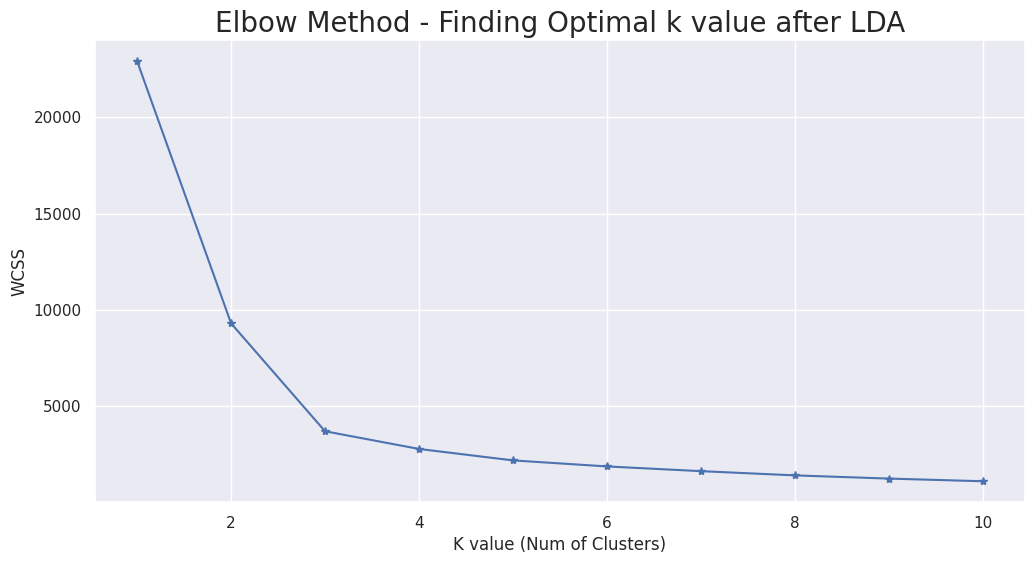

In [ ]:
wcss = {}
sns.set()
plt.figure(figsize=(12, 6))

for i in range(1, 11):
    km = KMeans(n_clusters=i, n_init=10, random_state=42)
    km.fit(ldadf)   # 👈 use LDA-reduced data instead of pcadf
    wcss[i] = km.inertia_

plt.plot(range(1, 11), wcss.values(), marker='*')
plt.title('Elbow Method - Finding Optimal k value after LDA', fontsize=20)
plt.xlabel('K value (Num of Clusters)')
plt.ylabel('WCSS')
plt.show()


#Silhoutte Score Plot for K-means to choose best number of Clusters

For n_clusters = 3 The average silhouette_score is : 0.6082218767171184
For n_clusters = 4 The average silhouette_score is : 0.5264773505874146
For n_clusters = 5 The average silhouette_score is : 0.4855674009406702
For n_clusters = 6 The average silhouette_score is : 0.4366349607160357


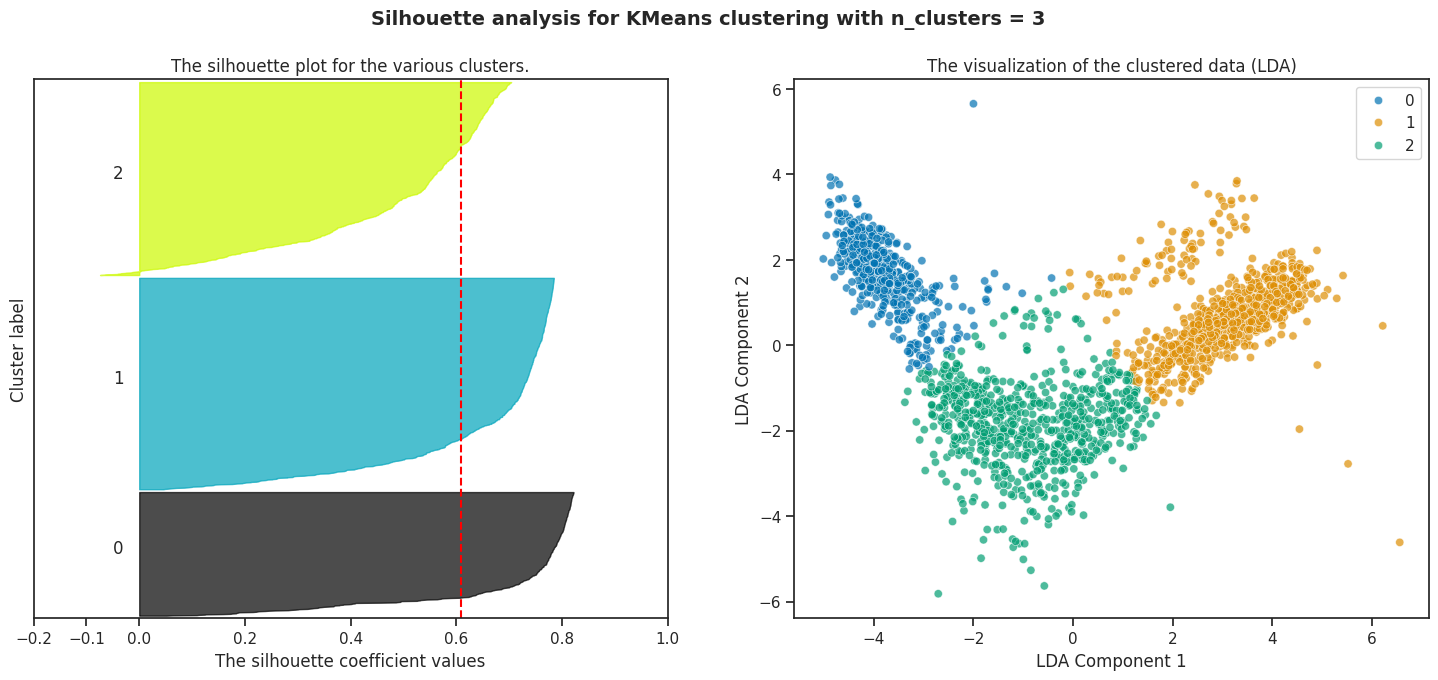

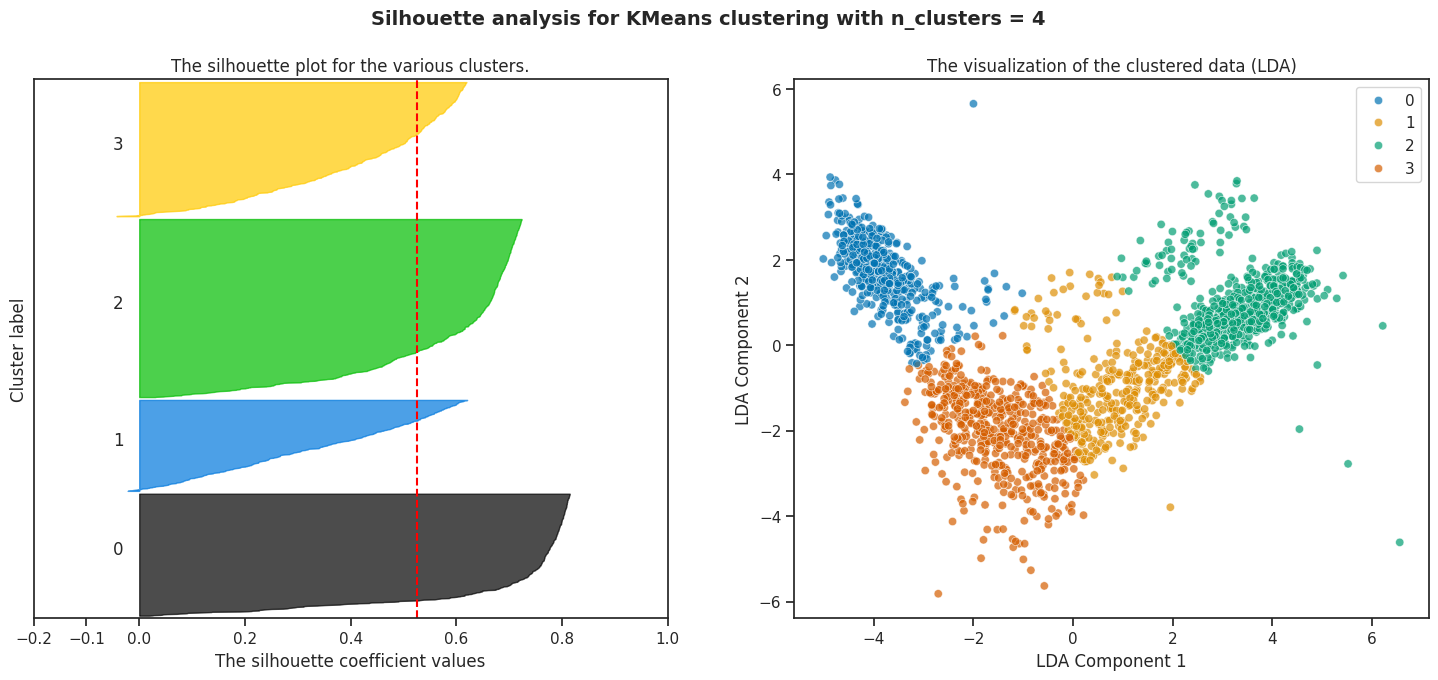

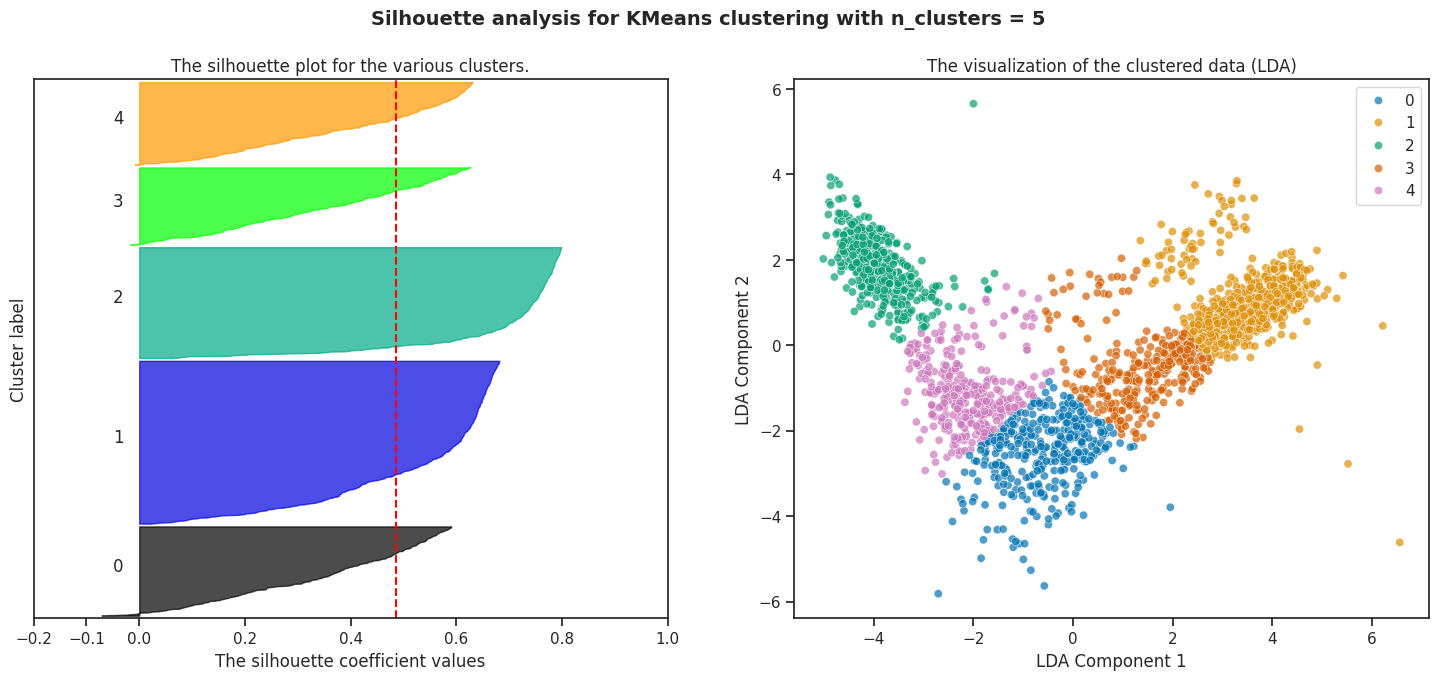

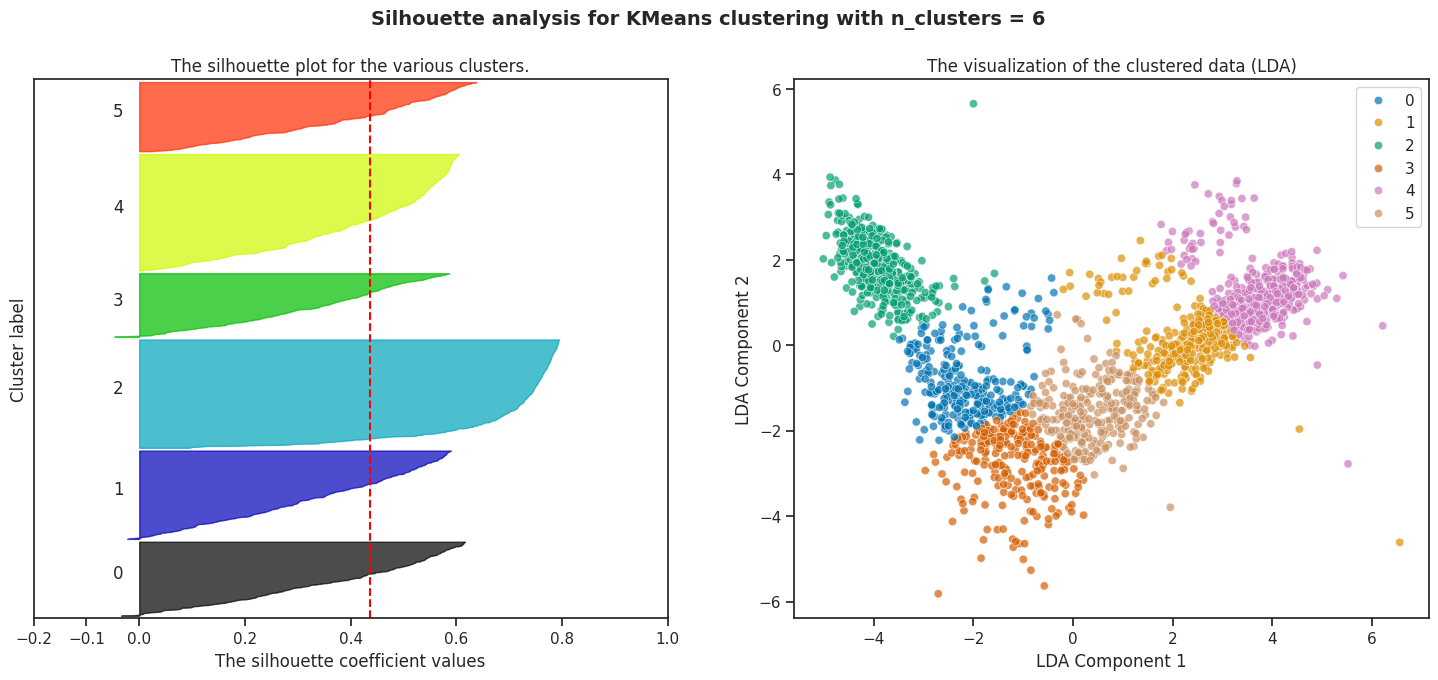

In [ ]:
# We plot silhouette score for KMeans
# Here ldadf is LDA dataframe, and reduced is array of data after LDA.
sns.set_style('ticks')
silhouette_plot(KMeans, range(3, 7), ldadf.values, ldadf.values)



#Report:

As **K = 3** gives the highest silhouette score, indicating the best cluster separation.
* Silhouette scores decrease as the number of clusters increases beyond 3.
* **3 clusters provide the best balance** between compactness (inertia) and separation.
* Therefore, **K = 3 is selected** as the optimal number of clusters for segmentation.



# Finalize K-Means Model:

To lock our segmentation Model.

In [ ]:
from sklearn.cluster import KMeans

k_opt = 3
kmeans_final = KMeans(n_clusters=k_opt, n_init=10, random_state=42)
df['final_cluster'] = kmeans_final.fit_predict(ldadf)


# Train Classifier to Predict Cluster:

In [ ]:
#Random Forest

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X = scaled_data.copy()
y = df['final_cluster']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))


Random Forest Accuracy: 0.9583333333333334


In [ ]:
#XGBoost

from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=len(y.unique()),
    eval_metric='mlogloss',
    random_state=42
)
xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred))


XGBoost Accuracy: 0.9828431372549019


In [ ]:
import pickle

pickle.dump(kmeans_final, open('kmeans_model.pkl', 'wb'))
pickle.dump(rf, open('classifier_model.pkl', 'wb'))  # or xgb
pickle.dump(preprocessor, open('preprocessor.pkl', 'wb'))
pickle.dump(lda_final, open('lda.pkl', 'wb'))
